In [ ]:
%pip install puremacro


# Mixed-Frequency GDP Nowcasting — Tracking the Real-Time Economy

**How can central banks and fiscal authorities estimate current-quarter GDP growth in real time before official statistical releases, and how can incoming data surprises be rigorously attributed to revisions?**

Official Gross Domestic Product (GDP) figures are published at a quarterly frequency and typically with a substantial lag of one to three months following the end of the reference quarter. In contrast, financial markets and policymakers require immediate assessments of macroeconomic momentum to guide interest rate decisions and emergency fiscal interventions. High-frequency indicators—such as industrial production, retail sales, purchasing managers' indices (PMI), and payroll employment—are published weekly or monthly, but they arrive with asynchronous release dates and differing publication delays. This generates an unbalanced panel with missing values at the end of the sample, known as the **ragged edge**.

Domenico Giannone, Lucrezia Reichlin, and David Small (2008, *Journal of Monetary Economics*) pioneered the state-space **Dynamic Factor Model (DFM)** framework to address this mixed-frequency challenge. By assuming that a large panel of monthly macroeconomic series is driven by a small number of pervasive unobserved latent factors $F_t$, the DFM achieves two key econometrics objectives:
1. **Signal Extraction with Missing Data**: The Kalman filter and Rauch-Tung-Striebel smoother handle time-varying observation patterns, projecting unobserved common trends through the ragged edge.
2. **Formal News Decomposition**: Marta Bańbura and Michele Modugno (2014, *Journal of Applied Econometrics*) formalized how to decompose the revision in the GDP nowcast $\Delta \hat{y}_{t|v} = \hat{y}_{t|v} - \hat{y}_{t|v-1}$ into the weighted sum of *news* (the unexpected surprise in each released series relative to its model forecast).

In this interactive showcase, we simulate an asynchronous monthly macroeconomic panel with ragged-edge publication lags, estimate the dynamic factor nowcast, and compute the exact news attribution matrix using `puremacro.nowcast.nowcast_gdp`.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.nowcast import nowcast_gdp

## 1. Simulating an Asynchronous Macroeconomic Panel

The state-space representation of the mixed-frequency Dynamic Factor Model consists of:

1. **Measurement Equation**:
   Let $X_t = (x_{1,t}, \dots, x_{N,t})^\top$ be a standardized vector of $N$ monthly indicators. Each series is decomposed into common factor variations and idiosyncratic noise:
   $$ X_t = \Lambda F_t + \xi_t, \quad \xi_t \sim \mathcal{N}(0, \Sigma_\xi) $$
   where $\Lambda \in \mathbb{R}^{N \times r}$ is the factor loadings matrix, $F_t \in \mathbb{R}^r$ is the vector of $r \ll N$ common factors, and $\Sigma_\xi = \text{diag}(\sigma_{\xi, 1}^2, \dots, \sigma_{\xi, N}^2)$ enforces cross-sectional orthogonality.
2. **Transition Equation**:
   The unobserved latent factors follow a stationary vector autoregression:
   $$ F_t = A_1 F_{t-1} + \dots + A_p F_{t-p} + u_t, \quad u_t \sim \mathcal{N}(0, Q) $$
3. **Quarterly Bridge Equation**:
   Quarterly GDP growth $y_q^Q$ is linked to the monthly common factors through a quarterly aggregation filter $\bar{F}_q = \frac{1}{3} \sum_{m \in q} F_{q, m}$:
   $$ y_q^Q = \mu + \beta^\top \bar{F}_q + \varepsilon_q, \quad \varepsilon_q \sim \mathcal{N}(0, \sigma_\varepsilon^2) $$

When a release is delayed, observation $x_{i,t}$ is unobserved. The measurement equation is projected onto the observed subspace via a time-varying selection matrix $M_t$: $X_t^{obs} = M_t X_t = M_t \Lambda F_t + M_t \xi_t$.

Below, we generate $T=72$ months of data for $N=10$ representative macroeconomic indicators, inserting missing values at the final date to mimic the empirical publication lag of surveys and hard data.

In [2]:
rng = np.random.default_rng(42)
n_months = 72
dates_m = pd.date_range("2018-01-01", periods=n_months, freq="MS")

F_true = np.zeros((n_months, 2))
for t in range(1, n_months):
    F_true[t, 0] = 0.85 * F_true[t-1, 0] + rng.normal(scale=0.8)
    F_true[t, 1] = 0.60 * F_true[t-1, 1] + rng.normal(scale=0.5)

var_names = [
    "Industrial Production", "Payroll Employment", "Retail Sales",
    "Housing Starts", "Capacity Utilization", "PMI Manufacturing",
    "Core CPI Inflation", "Real Personal Income", "Export Orders", "Consumer Sentiment"
]
N = len(var_names)
X = np.zeros((n_months, N))
for i in range(N):
    load = rng.uniform(0.4, 1.6, size=2)
    X[:, i] = F_true @ load + rng.normal(scale=0.4, size=n_months)

df_X = pd.DataFrame(X, index=dates_m, columns=var_names)
# Staggered release delays: hard indicators published with 1-month lag
df_X.iloc[-1, [3, 4, 8, 9]] = np.nan

# Historical quarterly GDP
dates_q = pd.date_range("2018-01-01", periods=n_months // 3, freq="QS")
F_q = df_X.resample("QE").mean().to_numpy().mean(axis=1)[:len(dates_q)]
gdp = 2.2 + 1.4 * F_q + rng.normal(scale=0.3, size=len(dates_q))
s_gdp = pd.Series(gdp, index=dates_q.to_period("Q").astype(str), name="GDP Growth")

## 2. Estimating the Dynamic Factor Nowcast & News Decomposition

Estimation proceeds via the Expectation-Maximization (EM) algorithm of Shumway & Stoffer (1982), which alternates between:
1. **E-step**: Running the Kalman smoother conditional on current parameter estimates $(\hat{\Lambda}, \hat{A}, \hat{\Sigma}_\xi, \hat{Q})$ to compute the expected factor trajectories $\mathbb{E}[F_t \mid X_{1:T}^{obs}]$.
2. **M-step**: Updating factor loadings and autoregressive matrices via generalized least squares regressions on the smoothed factor moments.

Once the DFM converges, the bridge equation maps the smoothed factor sequence into a point forecast for current-quarter GDP, providing an objective headline nowcast before official statistical compilation.

In [3]:
res = nowcast_gdp(df_X, s_gdp, n_factors=2)
print(res.summary())

Dynamic Factor Model GDP Nowcasting (Giannone, Reichlin & Small 2008)
Target Quarter                  : 2023Q4
GDP Growth Nowcast              : 4.41 (units of quarterly_gdp)
Quarterly Bridge Regression R²  : 0.9809
Latent Monthly Factors (K)      : 2
Target-quarter months forecast  : 0 (factor VAR)
--------------------------------------------------------------------------
Latest News & Contribution Decomposition:
  Industrial Production  | Surprise:  +0.12 | Impact: +0.009
  Payroll Employment     | Surprise:  +0.48 | Impact: +0.014
  Retail Sales           | Surprise:  -0.52 | Impact: -0.023
  PMI Manufacturing      | Surprise:  +0.23 | Impact: +0.015
  Core CPI Inflation     | Surprise:  +0.02 | Impact: +0.001
  Real Personal Income   | Surprise:  -0.46 | Impact: -0.017


## 3. Visualizing Latent Monthly Factors & Factor Loadings

The latent factors separate the aggregate business cycle into orthogonal economic forces:
- **Factor 1 (Real Activity Driver)**: Captures the co-movement across hard output series (industrial production, capacity utilization, and payrolls).
- **Factor 2 (Demand & Sentiment Driver)**: Reflects forward-looking consumer confidence, retail demand, and price pressure.

The factor loadings matrix $\Lambda$ (Right Panel) reveals the sensitivity of each indicator to the underlying common factors. Series with large positive loadings on Factor 1 serve as primary barometers of the real business cycle.

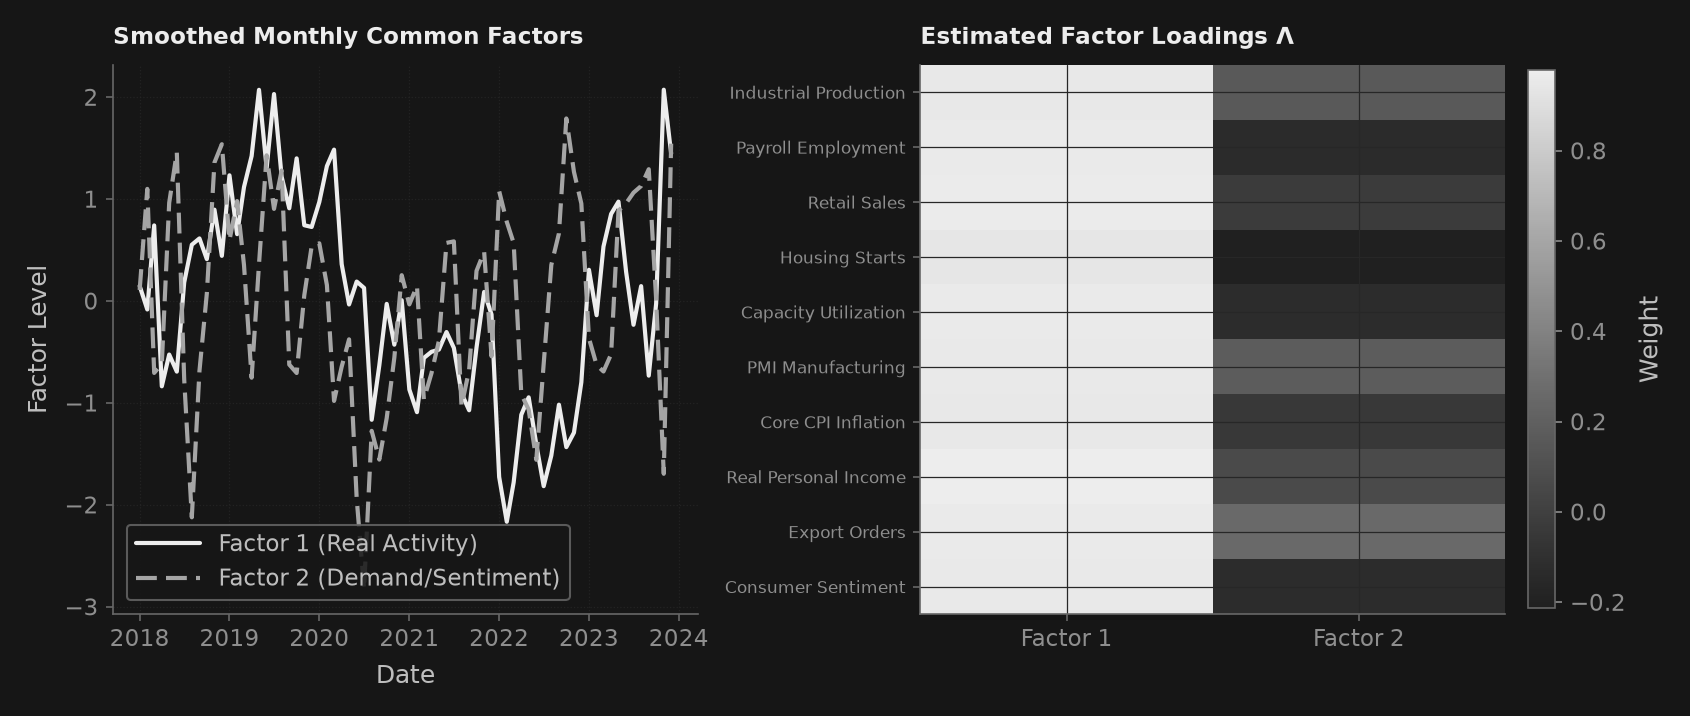

In [4]:
fig, (ax1, ax2) = _nbstyle.figura(1, 2, figsize=(11.0, 4.5))

ax1.plot(df_X.index, res.factors["Factor_1"], **_nbstyle.S1, label="Factor 1 (Real Activity)")
ax1.plot(df_X.index, res.factors["Factor_2"], **_nbstyle.S2, label="Factor 2 (Demand/Sentiment)")
ax1.set_title("Smoothed Monthly Common Factors", fontsize=11, fontweight="bold")
ax1.set_xlabel("Date", color=_nbstyle.TEXTO)
ax1.set_ylabel("Factor Level", color=_nbstyle.TEXTO)
ax1.legend(frameon=True, facecolor=_nbstyle.FONDO, edgecolor=_nbstyle.SPINE)
ax1.grid(True, linestyle=":", color=_nbstyle.REJILLA, alpha=0.8)

im = ax2.imshow(res.loadings.to_numpy(), cmap=_nbstyle.CMAP_SEQ, aspect="auto")
ax2.set_yticks(range(N))
ax2.set_yticklabels(var_names, fontsize=8)
ax2.set_xticks([0, 1])
ax2.set_xticklabels(["Factor 1", "Factor 2"])
ax2.set_title("Estimated Factor Loadings Λ", fontsize=11, fontweight="bold")
cbar = fig.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)
cbar.set_label("Weight", color=_nbstyle.TEXTO)
cbar.ax.tick_params(colors=_nbstyle.NOTA)

## 4. News and Revision Decomposition

The centerpiece of real-time monitoring is the **Bańbura & Modugno (2014) News Attribution**. When a statistical agency releases a new data vintage $v$ containing fresh observations $X_{new, v}$, the change in the GDP nowcast is given by:

$$ \hat{y}_{t \mid v} - \hat{y}_{t \mid v-1} = \sum_{j \in \text{released}} \omega_{j, v} \cdot \left[ x_{j, v} - \mathbb{E}(x_{j, v} \mid \Omega_{v-1}) \right] $$

where:
- $\text{Surprise}_{j, v} = x_{j, v} - \mathbb{E}(x_{j, v} \mid \Omega_{v-1})$ is the unexpected component of indicator $j$ relative to the prior market expectation.
- $\omega_{j, v} = \beta^\top \frac{\partial \mathbb{E}[F_t \mid \Omega_v]}{\partial x_{j, v}}$ is the econometric weight determined by the Kalman gain and the indicator's signal-to-noise ratio.

In the charts below:
- **Left Panel (Data Surprises)**: Displays standardized release surprises. A positive bar indicates the indicator outperformed model expectations.
- **Right Panel (Nowcast Impact)**: Shows the net contribution of each surprise to the overall GDP revision in percentage points. High-variance series with low factor loadings receive small weights, preventing erratic indicators from generating false revisions.

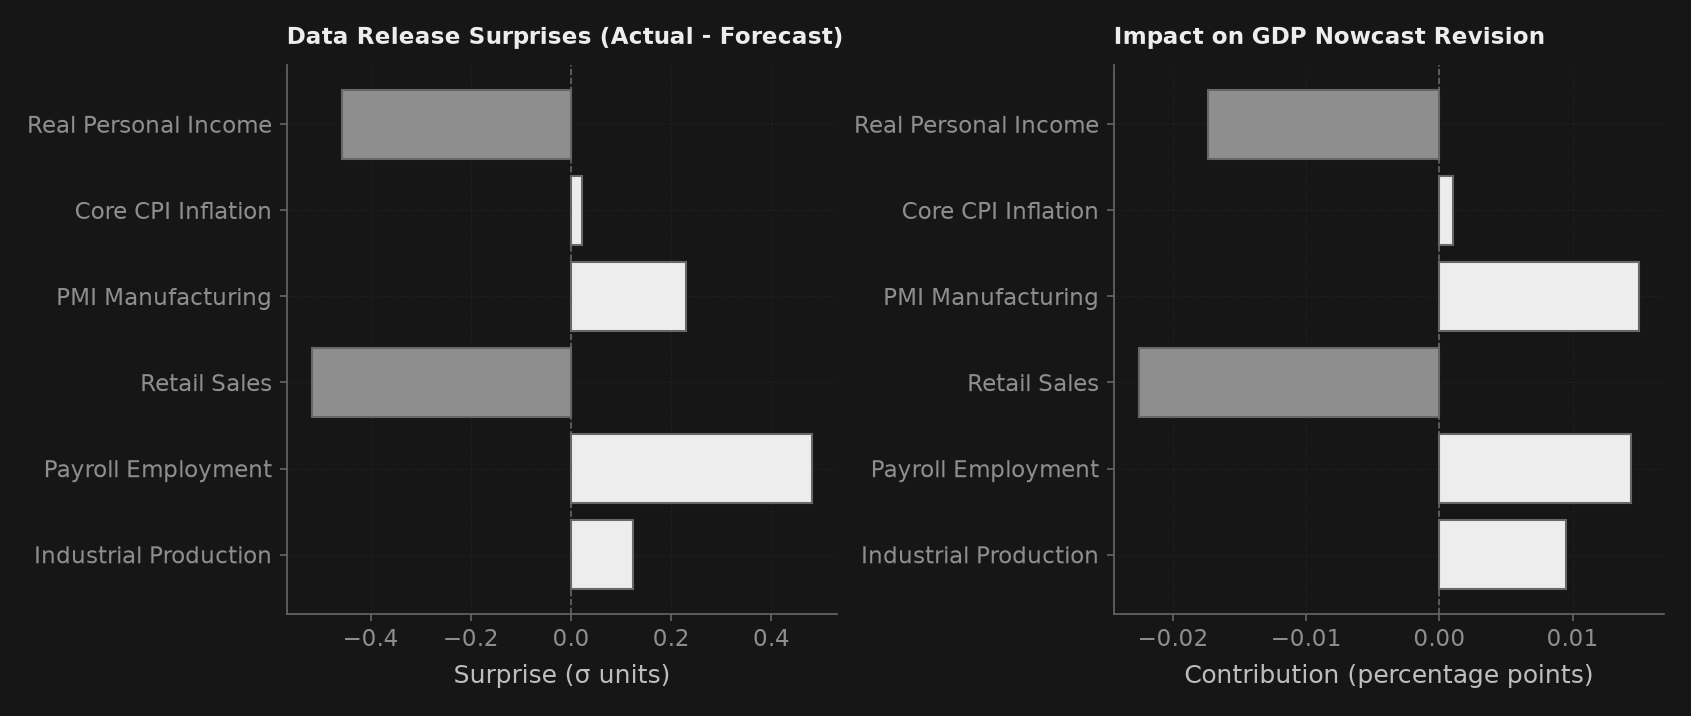

In [5]:
fig, (ax1, ax2) = _nbstyle.figura(1, 2, figsize=(11.0, 4.5))

if not res.news_decomposition.empty:
    surp = res.news_decomposition["surprise"].to_numpy()
    colors1 = [_nbstyle.TINTA if s >= 0 else _nbstyle.NOTA for s in surp]
    bars1 = ax1.barh(res.news_decomposition["series"], surp, color=colors1, edgecolor=_nbstyle.SPINE)
    ax1.set_title("Data Release Surprises (Actual - Forecast)", fontsize=11, fontweight="bold")
    ax1.set_xlabel("Surprise (σ units)", color=_nbstyle.TEXTO)
    ax1.axvline(0, color=_nbstyle.SPINE, lw=0.8, linestyle="--")
    ax1.grid(True, linestyle=":", color=_nbstyle.REJILLA, alpha=0.8)

    contrib = res.news_decomposition["contribution"].to_numpy()
    colors2 = [_nbstyle.TINTA if c >= 0 else _nbstyle.NOTA for c in contrib]
    bars2 = ax2.barh(res.news_decomposition["series"], contrib, color=colors2, edgecolor=_nbstyle.SPINE)
    ax2.set_title("Impact on GDP Nowcast Revision", fontsize=11, fontweight="bold")
    ax2.set_xlabel("Contribution (percentage points)", color=_nbstyle.TEXTO)
    ax2.axvline(0, color=_nbstyle.SPINE, lw=0.8, linestyle="--")
    ax2.grid(True, linestyle=":", color=_nbstyle.REJILLA, alpha=0.8)